# Lead-Time Analysis

This notebook evaluates how early the trained progression models can flag conversion, using truncated visit histories.

**Experimental setup recap** (see `leadtime.py`):
- For every **progressor** (`Prog_ID == 1`), the model is run on progressively longer visit-history truncations — starting at 2 visits, up to the full visit history (which includes the visit where conversion is recorded). Column `0` = prediction using the first 2 visits, column `1` = first 3 visits, etc.
- For every **non-progressor / control** (`Prog_ID == 0`), the same truncation scheme is applied (optionally masking the most recent visits), so any positive prediction is a false alarm since these subjects never actually progress.
- `months_since_baseline` gives the visit months for the *full, untruncated* sequence. Prediction column `i` (truncation length `i+2`) uses visits `[0 : i+2]`, so its "current" visit is index `i+1`, and the corresponding elapsed time is `months_since_baseline[i+1]`.
- For progressors, the final column's truncation includes the actual conversion visit, so `months_since_baseline[-1]` is the true conversion time. Lead time for a given alarm = `conversion_month - alarm_month`.

Below we compute detection/false-alarm rates and lead-time distributions for both cohorts.


In [1]:
import ast
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _parse_list(s):
    """Parse stringified list columns (months_since_baseline, Progression)."""
    if isinstance(s, str):
        return ast.literal_eval(s)
    return s


def _pred_cols(df):
    """Return the truncation-index prediction columns ('0', '1', ...), sorted numerically."""
    cols = [c for c in df.columns if c not in ('ID', 'months_since_baseline', 'Progression')]
    return sorted(cols, key=lambda x: int(x))


def load_leadtime_results(base_dir):
    """Load progressor (lead_time_*) and control (control_*) prediction csvs for a cohort dir."""
    prog_pred = pd.read_csv(os.path.join(base_dir, 'lead_time_predictions.csv'))
    ctrl_pred = pd.read_csv(os.path.join(base_dir, 'control_predictions.csv'))
    for df in (prog_pred, ctrl_pred):
        df['months_since_baseline'] = df['months_since_baseline'].apply(_parse_list)
        df['Progression'] = df['Progression'].apply(_parse_list)
    return prog_pred, ctrl_pred


def analyze_progressors(prog_pred):
    """For each progressor, find the first truncation at which the model raised an alarm (pred==1),
    and compute the resulting lead time relative to the true conversion visit."""
    pred_cols = _pred_cols(prog_pred)
    records = []
    for _, row in prog_pred.iterrows():
        months = row['months_since_baseline']
        conversion_month = months[-1]
        baseline_month = months[0]

        first_alarm_idx = None
        for c in pred_cols:
            val = row[c]
            if pd.notna(val) and val == 1:
                first_alarm_idx = int(c)
                break

        if first_alarm_idx is None:
            status = 'missed'
            lead_time = np.nan
            alarm_month = np.nan
        else:
            alarm_month = months[first_alarm_idx + 1]
            lead_time = conversion_month - alarm_month
            status = 'detected_early' if lead_time > 0 else 'detected_at_conversion'

        records.append({
            'ID': row['ID'],
            'baseline_month': baseline_month,
            'conversion_month': conversion_month,
            'alarm_month': alarm_month,
            'lead_time_months': lead_time,
            'status': status,
        })
    return pd.DataFrame(records)


def analyze_controls(ctrl_pred):
    """For each control (non-progressor), compute whether/how often the model raised a false alarm."""
    pred_cols = _pred_cols(ctrl_pred)
    records = []
    for _, row in ctrl_pred.iterrows():
        vals = [row[c] for c in pred_cols if pd.notna(row[c])]
        n_alarms = int(sum(v == 1 for v in vals))
        records.append({
            'ID': row['ID'],
            'n_visits_predicted': len(vals),
            'n_false_alarms': n_alarms,
            'any_false_alarm': n_alarms > 0,
            'false_alarm_rate': n_alarms / len(vals) if vals else np.nan,
        })
    return pd.DataFrame(records)


def summarize_leadtime(prog_df, ctrl_df, label=""):
    """Print sensitivity/specificity and lead-time stats for one cohort."""
    n_prog = len(prog_df)
    n_detected = int((prog_df['status'] != 'missed').sum())
    n_early = int((prog_df['status'] == 'detected_early').sum())
    n_at_conv = int((prog_df['status'] == 'detected_at_conversion').sum())
    n_missed = int((prog_df['status'] == 'missed').sum())
    sensitivity = n_detected / n_prog if n_prog else np.nan

    n_ctrl = len(ctrl_df)
    n_false_alarm = int(ctrl_df['any_false_alarm'].sum())
    specificity = 1 - n_false_alarm / n_ctrl if n_ctrl else np.nan

    lead_times = prog_df.loc[prog_df['status'] == 'detected_early', 'lead_time_months']

    print(f"===== {label} Lead-Time Analysis =====")
    print(f"Progressors: {n_prog}")
    print(f"  Detected (any point):            {n_detected:3d} ({sensitivity:.1%})")
    print(f"    - Detected early (pre-conversion): {n_early:3d} ({n_early/n_prog:.1%})")
    print(f"    - Detected only at conversion:     {n_at_conv:3d} ({n_at_conv/n_prog:.1%})")
    print(f"  Missed entirely:                  {n_missed:3d} ({n_missed/n_prog:.1%})")
    if len(lead_times):
        print(f"  Lead time (months) among early detections: "
              f"mean={lead_times.mean():.1f}, median={lead_times.median():.1f}, "
              f"min={lead_times.min():.1f}, max={lead_times.max():.1f}")
    print(f"\nControls (non-progressors): {n_ctrl}")
    print(f"  False alarms (>=1 visit): {n_false_alarm:3d} ({n_false_alarm/n_ctrl:.1%})")
    print(f"  Specificity: {specificity:.1%}")

    return {
        'n_prog': n_prog, 'n_detected': n_detected, 'n_early': n_early,
        'n_at_conv': n_at_conv, 'n_missed': n_missed, 'sensitivity': sensitivity,
        'n_ctrl': n_ctrl, 'n_false_alarm': n_false_alarm, 'specificity': specificity,
        'lead_times': lead_times,
    }


def plot_leadtime_summary(prog_df, ctrl_df, label=""):
    """Plot detection outcome breakdown, lead-time distribution, and control false-alarm rate."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    status_order = ['detected_early', 'detected_at_conversion', 'missed']
    status_counts = prog_df['status'].value_counts().reindex(status_order, fill_value=0)
    axes[0].bar(['Early', 'At conversion', 'Missed'], status_counts.values,
                color=['#2ca02c', '#ff7f0e', '#d62728'])
    axes[0].set_title(f"{label}: Progressor Detection Outcomes")
    axes[0].set_ylabel("Number of subjects")

    lead_times = prog_df.loc[prog_df['status'] == 'detected_early', 'lead_time_months']
    if len(lead_times):
        axes[1].hist(lead_times, bins=15, color='#1f77b4', edgecolor='white')
    axes[1].set_title(f"{label}: Lead Time Distribution")
    axes[1].set_xlabel("Months before conversion")
    axes[1].set_ylabel("Count")

    fa_counts = ctrl_df['any_false_alarm'].value_counts().reindex([False, True], fill_value=0)
    axes[2].bar(['No alarm', 'False alarm'], fa_counts.values, color=['#2ca02c', '#d62728'])
    axes[2].set_title(f"{label}: Control False Alarms")
    axes[2].set_ylabel("Number of subjects")

    plt.tight_layout()
    plt.show()


## CN_MCI results

1. Analyze the false positive / true positive rates of predictions, how many conversions were predicted early, how many predictions were false alarms. This is a clinical diagnostic trial on a small subset. 
2. Produce a chart and some visualizations. 

In [2]:
cn_prog_pred, cn_ctrl_pred = load_leadtime_results('CN')

cn_prog_df = analyze_progressors(cn_prog_pred)
cn_ctrl_df = analyze_controls(cn_ctrl_pred)

cn_stats = summarize_leadtime(cn_prog_df, cn_ctrl_df, label='CN_MCI')


===== CN_MCI Lead-Time Analysis =====
Progressors: 119
  Detected (any point):            108 (90.8%)
    - Detected early (pre-conversion):  76 (63.9%)
    - Detected only at conversion:      32 (26.9%)
  Missed entirely:                   11 (9.2%)
  Lead time (months) among early detections: mean=44.4, median=36.5, min=9.4, max=130.7

Controls (non-progressors): 526
  False alarms (>=1 visit):  84 (16.0%)
  Specificity: 84.0%


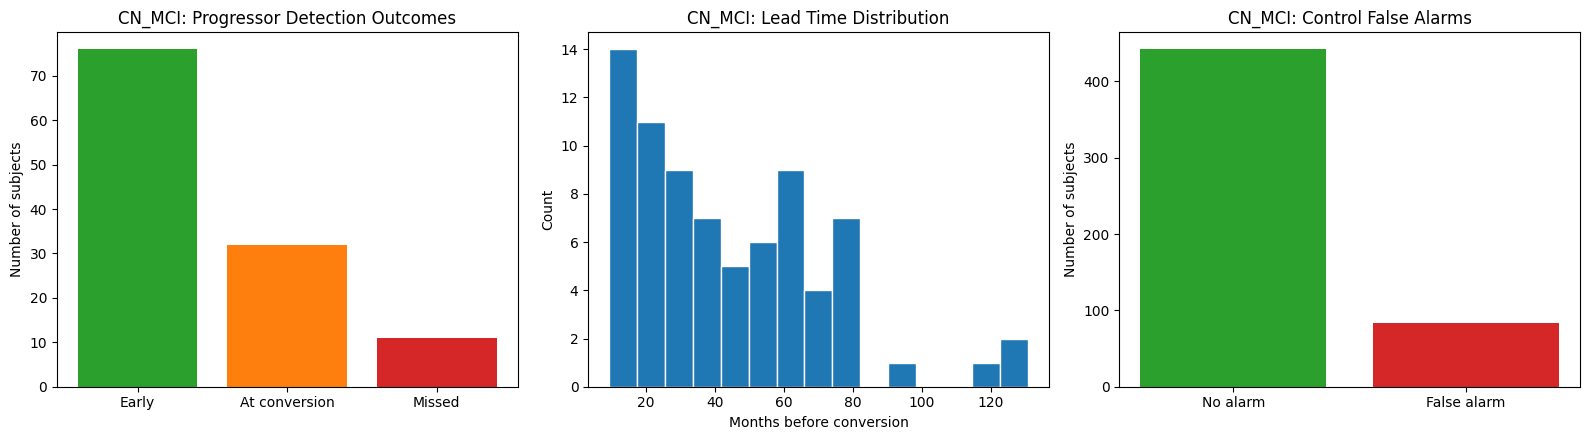

,ID,baseline_month,conversion_month,alarm_month,lead_time_months,status
115,NACC615860,0.0,142.74,12.02,130.72,detected_early
93,NACC136846,0.0,136.30,11.99,124.31,detected_early
104,NACC576836,0.0,138.24,16.29,121.95,detected_early
113,NACC839325,0.0,110.09,12.84,97.25,detected_early
102,NACC223876,0.0,107.65,25.99,81.66,detected_early
100,NACC219367,0.0,108.44,28.29,80.15,detected_early
75,NACC819869,0.0,94.71,15.47,79.24,detected_early
97,NACC326959,0.0,90.14,11.27,78.87,detected_early
109,NACC614575,0.0,100.99,24.51,76.48,detected_early
71,NACC666849,0.0,87.78,11.33,76.45,detected_early


In [3]:
plot_leadtime_summary(cn_prog_df, cn_ctrl_df, label='CN_MCI')
cn_prog_df.sort_values('lead_time_months', ascending=False).head(10)


## MCI_AD results

In [4]:
mci_prog_pred, mci_ctrl_pred = load_leadtime_results('MCI_AD')

mci_prog_df = analyze_progressors(mci_prog_pred)
mci_ctrl_df = analyze_controls(mci_ctrl_pred)

mci_stats = summarize_leadtime(mci_prog_df, mci_ctrl_df, label='MCI_AD')


===== MCI_AD Lead-Time Analysis =====
Progressors: 79
  Detected (any point):             62 (78.5%)
    - Detected early (pre-conversion):  49 (62.0%)
    - Detected only at conversion:      13 (16.5%)
  Missed entirely:                   17 (21.5%)
  Lead time (months) among early detections: mean=37.1, median=33.3, min=7.9, max=100.3

Controls (non-progressors): 78
  False alarms (>=1 visit):   8 (10.3%)
  Specificity: 89.7%


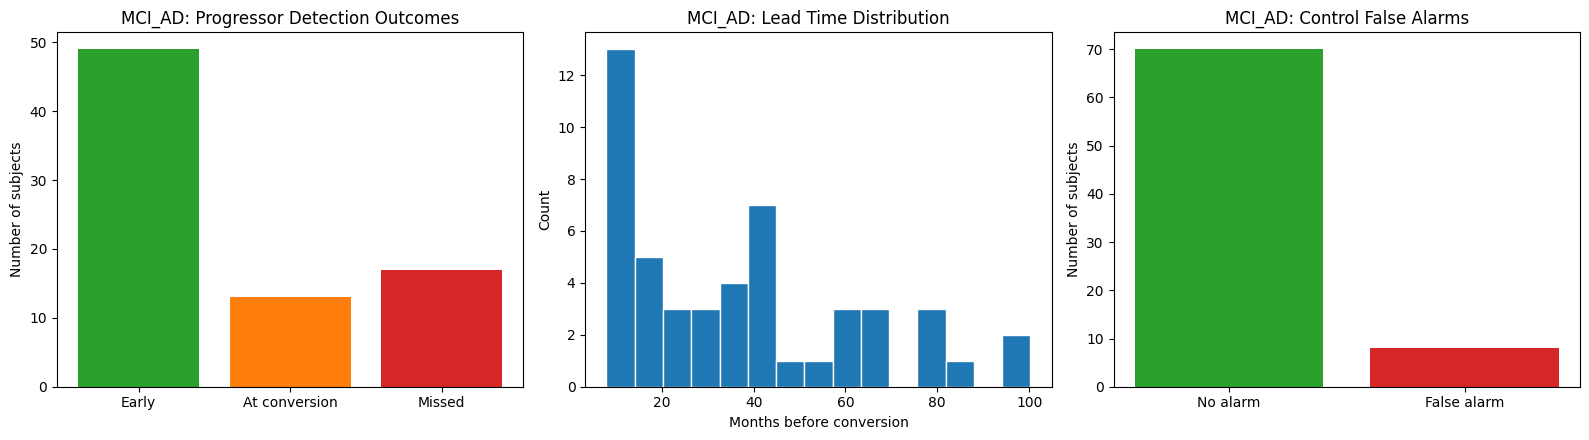

,ID,baseline_month,conversion_month,alarm_month,lead_time_months,status
78,NACC889008,0.0,126.08,25.79,100.29,detected_early
77,NACC829412,0.0,108.57,12.16,96.41,detected_early
73,NACC510442,0.0,108.84,22.60,86.24,detected_early
63,NACC413660,0.0,90.11,11.27,78.84,detected_early
69,NACC055816,0.0,114.26,35.87,78.39,detected_early
70,NACC867814,0.0,90.34,14.65,75.69,detected_early
74,NACC097876,0.0,97.50,28.78,68.72,detected_early
71,NACC267197,0.0,84.49,16.79,67.70,detected_early
75,NACC527308,0.0,97.27,30.81,66.46,detected_early
59,NACC333104,0.0,82.13,21.62,60.51,detected_early


In [5]:
plot_leadtime_summary(mci_prog_df, mci_ctrl_df, label='MCI_AD')
mci_prog_df.sort_values('lead_time_months', ascending=False).head(10)


## Cohort Comparison


In [6]:
comparison = pd.DataFrame({
    'CN_MCI': {
        'n_progressors': cn_stats['n_prog'],
        'sensitivity': cn_stats['sensitivity'],
        'pct_detected_early': cn_stats['n_early'] / cn_stats['n_prog'],
        'pct_detected_at_conversion': cn_stats['n_at_conv'] / cn_stats['n_prog'],
        'pct_missed': cn_stats['n_missed'] / cn_stats['n_prog'],
        'mean_lead_time_months': cn_stats['lead_times'].mean(),
        'median_lead_time_months': cn_stats['lead_times'].median(),
        'n_controls': cn_stats['n_ctrl'],
        'specificity': cn_stats['specificity'],
    },
    'MCI_AD': {
        'n_progressors': mci_stats['n_prog'],
        'sensitivity': mci_stats['sensitivity'],
        'pct_detected_early': mci_stats['n_early'] / mci_stats['n_prog'],
        'pct_detected_at_conversion': mci_stats['n_at_conv'] / mci_stats['n_prog'],
        'pct_missed': mci_stats['n_missed'] / mci_stats['n_prog'],
        'mean_lead_time_months': mci_stats['lead_times'].mean(),
        'median_lead_time_months': mci_stats['lead_times'].median(),
        'n_controls': mci_stats['n_ctrl'],
        'specificity': mci_stats['specificity'],
    },
}).T

comparison


,n_progressors,sensitivity,pct_detected_early,pct_detected_at_conversion,pct_missed,mean_lead_time_months,median_lead_time_months,n_controls,specificity
CN_MCI,119.0,0.907563,0.638655,0.268908,0.092437,44.431316,36.52,526.0,0.840304
MCI_AD,79.0,0.784810,0.620253,0.164557,0.215190,37.144286,33.34,78.0,0.897436


Fixing some issues with lead time code. 


Processing non‑imputed – CN_MCI ( 10 models )...
Processing non‑imputed – MCI_AD ( 10 models )...
Processing MICE‑imputed – CN_MCI ( 10 models )...
Processing MICE‑imputed – MCI_AD ( 10 models )...


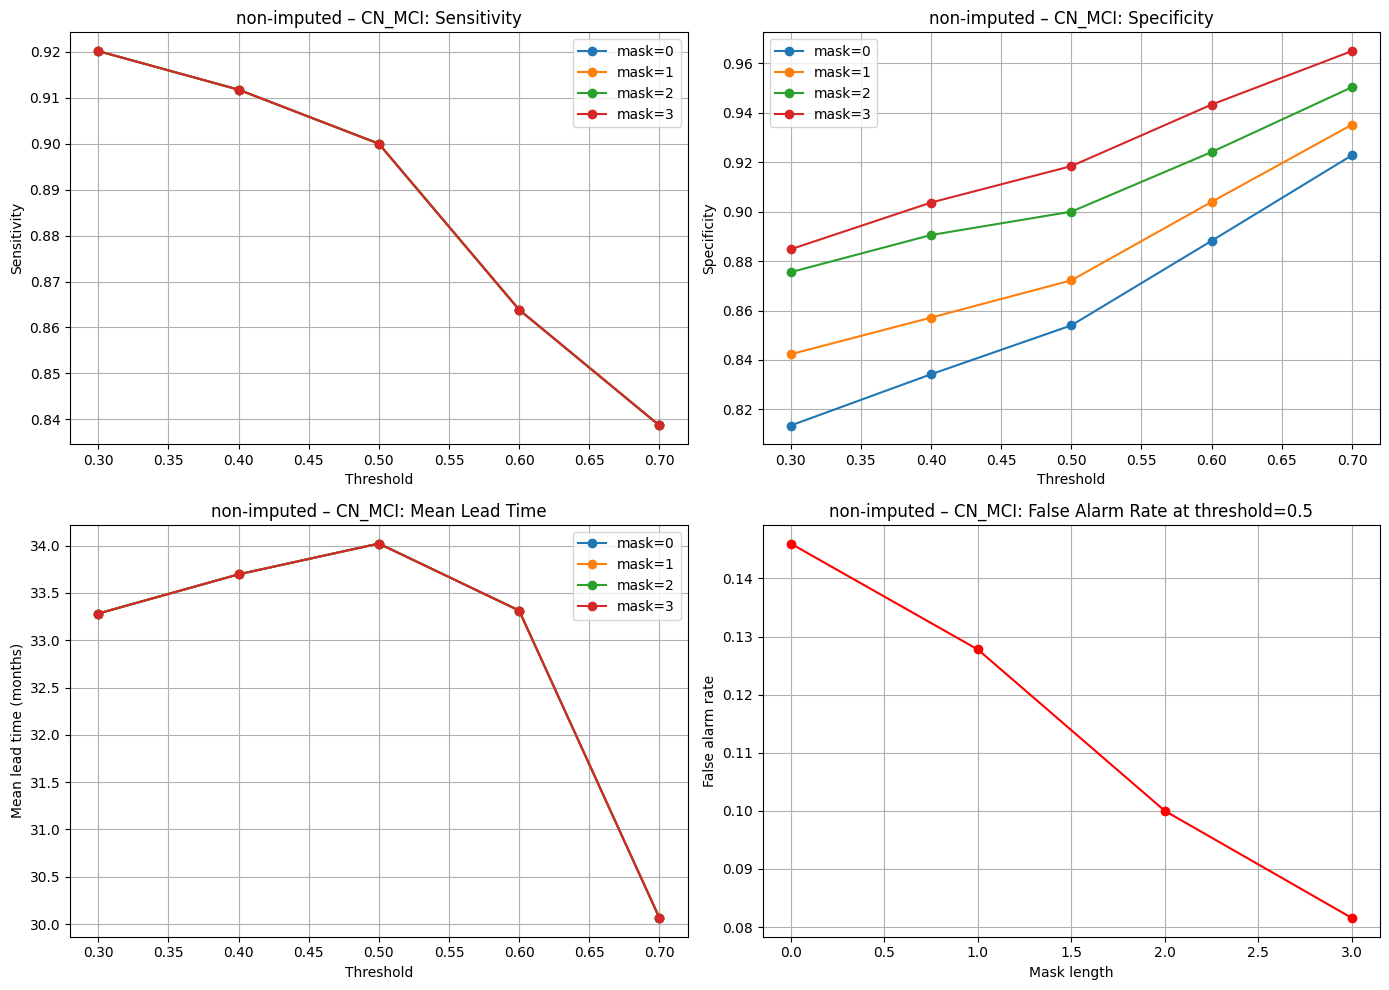

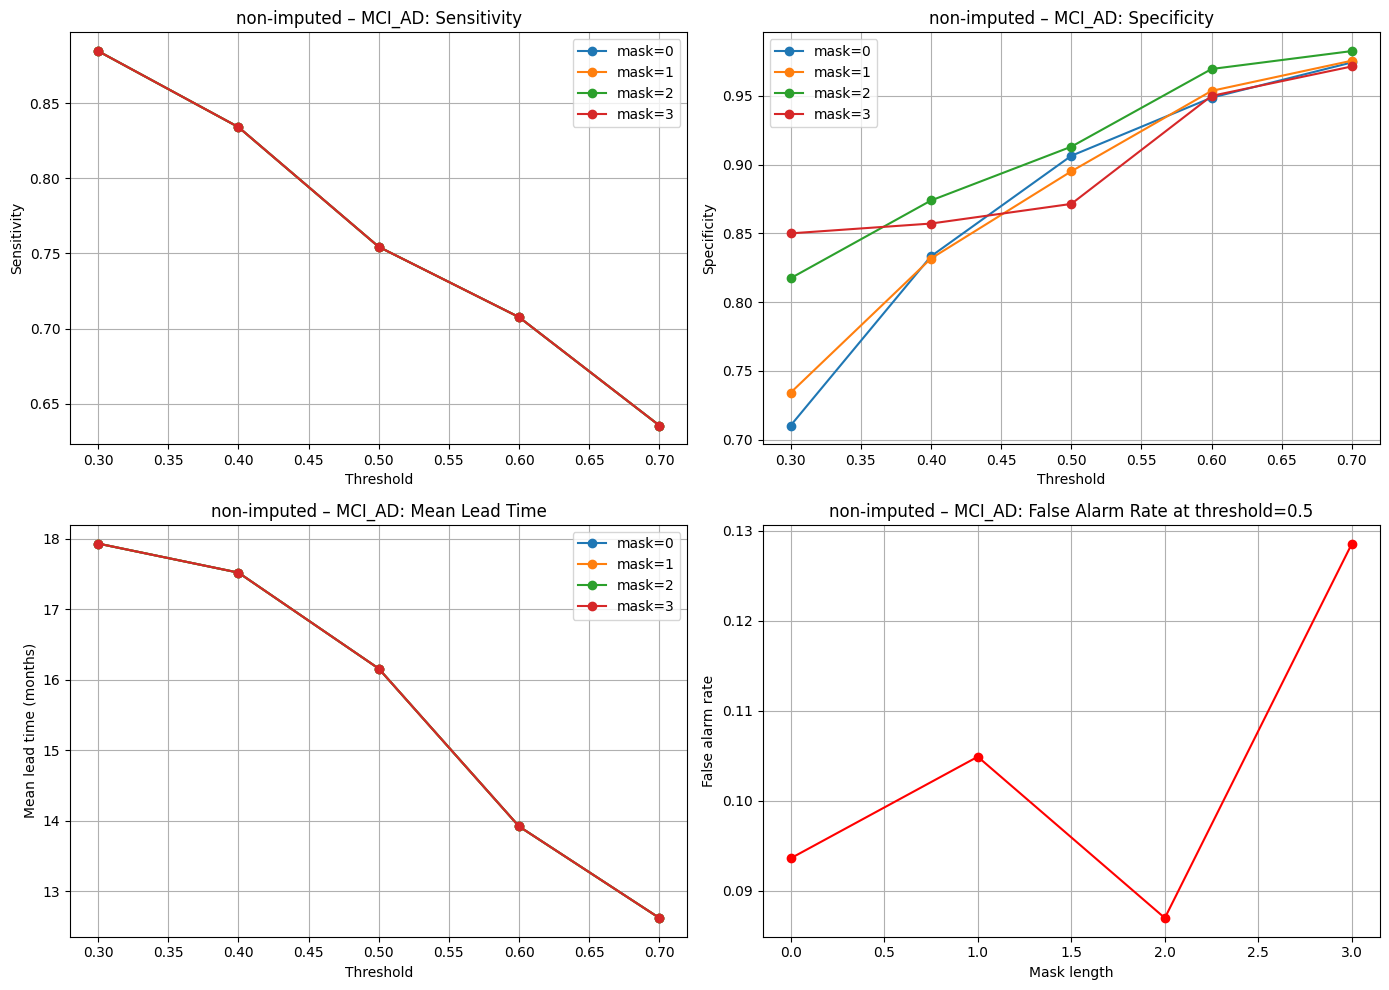

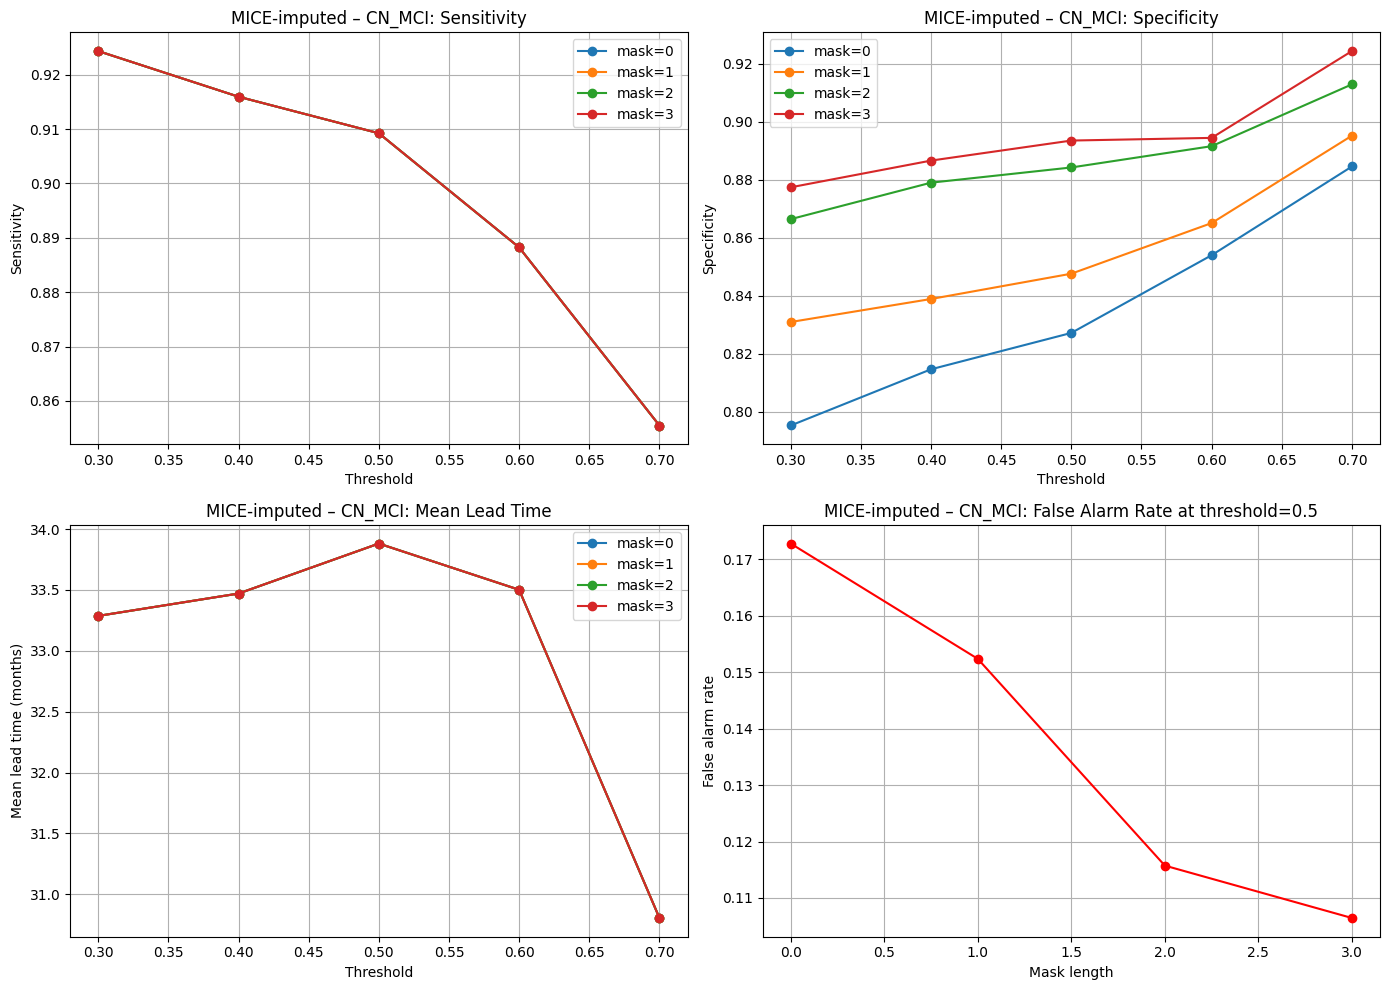

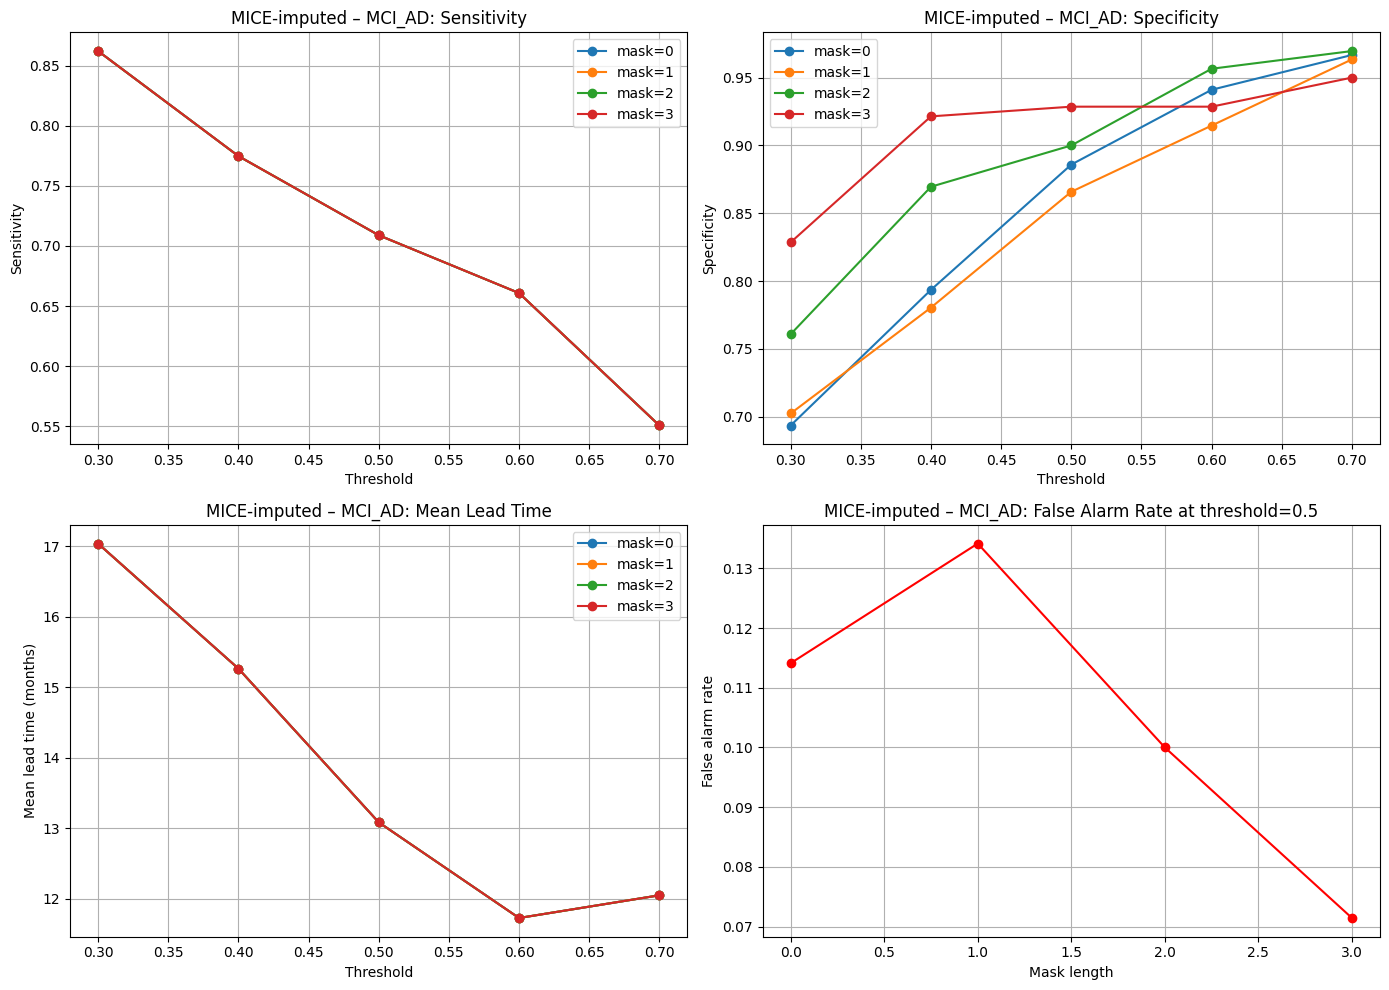

In [7]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import joblib
import glob
import tempfile
import shutil
import ast

# ── Locate workspace root (directory containing leadtime.py) ───────────────
cwd = Path.cwd().resolve()
WORKSPACE_ROOT = None
for base in [cwd, *cwd.parents]:
    if (base / "leadtime.py").exists():
        WORKSPACE_ROOT = base
        if str(base) not in sys.path:
            sys.path.insert(0, str(base))
        break
if WORKSPACE_ROOT is None:
    raise FileNotFoundError("Could not locate leadtime.py in any parent directory of the notebook.")

from leadtime import run_leadtime, _parse_list

# ── Helper: t‑based confidence interval ─────────────────────────────────────
def mean_ci(data, conf=0.95):
    n = len(data)
    if n < 2:
        return np.nan, np.nan, np.nan, np.nan
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    sem = std / np.sqrt(n)
    ci = stats.t.ppf((1 + conf) / 2, df=n - 1) * sem
    return mean, mean - ci, mean + ci, std

# ── Load models from an experiment directory ────────────────────────────────
def load_models(experiment_dir, progression_type):
    """
    Load all models for a given progression_type ('CN' or 'AD') from the experiment folder.
    Returns a dict {key: model_object}.
    """
    pattern = f"*_model_{progression_type}.pkl"
    model_paths = glob.glob(os.path.join(experiment_dir, pattern))
    models = {}
    for pkl in model_paths:
        key = os.path.basename(pkl).replace(f"_model_{progression_type}.pkl", "")
        models[key] = joblib.load(pkl)
    return models

# ── Generate or load probability DataFrames for a list of models ──────────
def get_probabilities(models_dict, leadtime_csv, prog_type, cache_dir="leadtime_cache"):
    """
    For each model, run run_leadtime (with mask_length=0) and read the probability CSVs.
    Saves CSVs in a cache directory to avoid recomputation.
    Returns a dict {key: {'prog': prog_df, 'ctrl': ctrl_df}}.
    """
    os.makedirs(cache_dir, exist_ok=True)
    results = {}
    for key, model in models_dict.items():
        # Use a subfolder per model to avoid collisions
        model_cache = os.path.join(cache_dir, key)
        os.makedirs(model_cache, exist_ok=True)
        prog_prob_path = os.path.join(model_cache, 'lead_time_probabilities.csv')
        ctrl_prob_path = os.path.join(model_cache, 'control_probabilities.csv')
        
        # If CSVs already exist, load them; otherwise generate
        if os.path.exists(prog_prob_path) and os.path.exists(ctrl_prob_path):
            prog_df = pd.read_csv(prog_prob_path)
            ctrl_df = pd.read_csv(ctrl_prob_path)
        else:
            # Run leadtime analysis (this will write CSVs to model_cache)
            run_leadtime(leadtime_csv, model_cache, model, prog_type, mask_length=0)
            prog_df = pd.read_csv(prog_prob_path)
            ctrl_df = pd.read_csv(ctrl_prob_path)
        
        # Parse list columns
        for df in (prog_df, ctrl_df):
            df['months_since_baseline'] = df['months_since_baseline'].apply(_parse_list)
            df['Progression'] = df['Progression'].apply(_parse_list)
        results[key] = {'prog': prog_df, 'ctrl': ctrl_df}
    return results

# ── Find true conversion month ──────────────────────────────────────────────
def get_conversion_month(progression, months):
    """
    progression: list of ints (0,1,2)
    months: list of month values
    Returns the month of the first visit where progression > progression[0].
    """
    start = progression[0]
    for i, val in enumerate(progression):
        if val > start:
            return months[i]
    # Fallback: if no progression (should not happen for progressors)
    return months[-1]

# ── Analyze a single run with given threshold and mask_length ──────────────
def analyze_run(prog_prob_df, ctrl_prob_df, threshold, mask_length):
    """
    Compute metrics for one model's probability DataFrames.
    Returns a dict with key metrics.
    """
    # Progressors
    pred_cols = sorted([c for c in prog_prob_df.columns if c.isdigit()], key=int)
    prog_records = []
    for _, row in prog_prob_df.iterrows():
        months = row['months_since_baseline']
        progression = row['Progression']
        true_conv_month = get_conversion_month(progression, months)
        # Get probabilities for each truncation
        probs = [row[c] for c in pred_cols if pd.notna(row[c])]
        # Find first alarm
        alarm_idx = None
        for i, p in enumerate(probs):
            if p >= threshold:
                alarm_idx = i
                break
        if alarm_idx is None:
            status = 'missed'
            alarm_month = np.nan
            lead_time = np.nan
        else:
            # The 'current' visit for truncation i is at index i+1
            alarm_month = months[alarm_idx + 1]
            lead_time = true_conv_month - alarm_month
            status = 'detected_early' if lead_time > 0 else 'detected_at_conversion'
        prog_records.append({
            'true_conversion_month': true_conv_month,
            'alarm_month': alarm_month,
            'lead_time': lead_time,
            'status': status,
        })
    prog_df = pd.DataFrame(prog_records)
    
    # Controls (with mask_length)
    ctrl_records = []
    for _, row in ctrl_prob_df.iterrows():
        months = row['months_since_baseline']
        n_visits = len(months)
        max_trunc = n_visits - mask_length - 2  # truncation 0 uses 2 visits
        if max_trunc < 0:
            continue
        probs = []
        for i in range(max_trunc + 1):
            c = str(i)
            if c in row and pd.notna(row[c]):
                probs.append(row[c])
        if not probs:
            continue
        alarms = [p >= threshold for p in probs]
        n_alarms = sum(alarms)
        ctrl_records.append({
            'n_visits_used': len(probs),
            'n_alarms': n_alarms,
            'any_alarm': n_alarms > 0,
        })
    ctrl_df = pd.DataFrame(ctrl_records)
    
    # Aggregate
    n_prog = len(prog_df)
    n_detected = (prog_df['status'] != 'missed').sum()
    n_early = (prog_df['status'] == 'detected_early').sum()
    n_at_conv = (prog_df['status'] == 'detected_at_conversion').sum()
    n_missed = (prog_df['status'] == 'missed').sum()
    sensitivity = n_detected / n_prog if n_prog else np.nan
    lead_times = prog_df.loc[prog_df['status'] == 'detected_early', 'lead_time']
    mean_lead = lead_times.mean() if len(lead_times) else np.nan
    median_lead = lead_times.median() if len(lead_times) else np.nan
    
    n_ctrl = len(ctrl_df)
    n_false_alarm = ctrl_df['any_alarm'].sum() if n_ctrl else 0
    specificity = 1 - n_false_alarm / n_ctrl if n_ctrl else np.nan
    false_alarm_rate = n_false_alarm / n_ctrl if n_ctrl else np.nan
    
    return {
        'n_prog': n_prog,
        'n_detected': n_detected,
        'n_early': n_early,
        'n_at_conv': n_at_conv,
        'n_missed': n_missed,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'mean_lead_time': mean_lead,
        'median_lead_time': median_lead,
        'false_alarm_rate': false_alarm_rate,
        'n_ctrl': n_ctrl,
        'n_false_alarm': n_false_alarm,
    }

# ── Run grid over thresholds and mask lengths for a collection of models ───
def run_grid(prob_dict, thresholds, mask_lengths):
    """
    prob_dict: {key: {'prog': df, 'ctrl': df}}
    Returns a DataFrame with columns: model_key, threshold, mask_length, metric...
    """
    rows = []
    for key, dfs in prob_dict.items():
        for thr in thresholds:
            for mask in mask_lengths:
                res = analyze_run(dfs['prog'], dfs['ctrl'], thr, mask)
                rows.append({
                    'model_key': key,
                    'threshold': thr,
                    'mask_length': mask,
                    **res
                })
    return pd.DataFrame(rows)

# ── Aggregate grid results across models ────────────────────────────────────
def aggregate_grid(df_grid):
    """
    Group by threshold and mask_length, compute mean, std, CI for each metric.
    """
    group_cols = ['threshold', 'mask_length']
    metrics = ['sensitivity', 'specificity', 'mean_lead_time', 'false_alarm_rate',
               'n_early', 'n_missed', 'n_false_alarm']
    agg_list = []
    for (thr, mask), group in df_grid.groupby(group_cols):
        row = {'threshold': thr, 'mask_length': mask}
        for m in metrics:
            vals = group[m].dropna().values
            if len(vals) > 1:
                mean, lo, hi, std = mean_ci(vals)
                row[f'{m}_mean'] = mean
                row[f'{m}_std'] = std
                row[f'{m}_ci_lower'] = lo
                row[f'{m}_ci_upper'] = hi
            elif len(vals) == 1:
                row[f'{m}_mean'] = vals[0]
                row[f'{m}_std'] = np.nan
                row[f'{m}_ci_lower'] = np.nan
                row[f'{m}_ci_upper'] = np.nan
            else:
                row[f'{m}_mean'] = np.nan
                row[f'{m}_std'] = np.nan
                row[f'{m}_ci_lower'] = np.nan
                row[f'{m}_ci_upper'] = np.nan
        agg_list.append(row)
    return pd.DataFrame(agg_list)

# ── Main execution ──────────────────────────────────────────────────────────

# 1. Define experiment directories and lead-time datasets (resolved from workspace root,
#    since the notebook's own cwd is "lead_time results/", not the workspace root)
NON_IMP_DIR = str(WORKSPACE_ROOT / "experiments" / "experiment_non_imputed_final")
MICE_DIR = str(WORKSPACE_ROOT / "experiments" / "experiment_mice_imputed_final")
leadtime_files = {
    "CN_MCI": str(WORKSPACE_ROOT / "datasets" / "Dataset_v2_1" / "lead_time_CN.csv"),
    "MCI_AD": str(WORKSPACE_ROOT / "datasets" / "Dataset_v2_1" / "lead_time_MCI_AD.csv"),
}

# 2. Load models (CN and AD) from both experiments
non_imp_models_cn = load_models(NON_IMP_DIR, "CN")
non_imp_models_ad = load_models(NON_IMP_DIR, "AD")
mice_models_cn = load_models(MICE_DIR, "CN")
mice_models_ad = load_models(MICE_DIR, "AD")

# Combine into dictionaries by imputation and cohort
models_by_imputation = {
    "non‑imputed": {"CN_MCI": non_imp_models_cn, "MCI_AD": non_imp_models_ad},
    "MICE‑imputed": {"CN_MCI": mice_models_cn, "MCI_AD": mice_models_ad},
}

# 3. Define grid
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
mask_lengths = [0, 1, 2, 3]

# 4. Cache directory for probabilities (to avoid rerunning models repeatedly)
CACHE_DIR = "leadtime_prob_cache"

# 5. Loop over imputation strategies and cohorts
all_results = {}  # {imputation: {cohort: agg_df}}
for imp, cohorts in models_by_imputation.items():
    all_results[imp] = {}
    for cohort, models_dict in cohorts.items():
        if not models_dict:
            print(f"No models for {imp} – {cohort}")
            continue
        prog_type = "CN" if cohort == "CN_MCI" else "AD"
        lead_csv = leadtime_files[cohort]
        print(f"Processing {imp} – {cohort} ( {len(models_dict)} models )...")
        # Get probability DataFrames
        prob_dict = get_probabilities(models_dict, lead_csv, prog_type, 
                                      cache_dir=os.path.join(CACHE_DIR, imp, cohort))
        # Run grid
        df_grid = run_grid(prob_dict, thresholds, mask_lengths)
        # Aggregate
        agg_df = aggregate_grid(df_grid)
        all_results[imp][cohort] = agg_df
        # Optionally save the grid and agg to CSV
        agg_df.to_csv(f"leadtime_agg_{imp}_{cohort}.csv", index=False)

# ── Plot results ────────────────────────────────────────────────────────────

# For each imputation and cohort, plot key metrics
for imp, cohorts in all_results.items():
    for cohort, agg_df in cohorts.items():
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        # 1. Sensitivity vs threshold, coloured by mask_length
        ax = axes[0, 0]
        for mask in mask_lengths:
            sub = agg_df[agg_df['mask_length'] == mask]
            ax.plot(sub['threshold'], sub['sensitivity_mean'], 'o-', label=f'mask={mask}')
        ax.set_xlabel('Threshold')
        ax.set_ylabel('Sensitivity')
        ax.set_title(f'{imp} – {cohort}: Sensitivity')
        ax.legend()
        ax.grid(True)
        
        # 2. Specificity vs threshold
        ax = axes[0, 1]
        for mask in mask_lengths:
            sub = agg_df[agg_df['mask_length'] == mask]
            ax.plot(sub['threshold'], sub['specificity_mean'], 'o-', label=f'mask={mask}')
        ax.set_xlabel('Threshold')
        ax.set_ylabel('Specificity')
        ax.set_title(f'{imp} – {cohort}: Specificity')
        ax.legend()
        ax.grid(True)
        
        # 3. Mean lead time vs threshold
        ax = axes[1, 0]
        for mask in mask_lengths:
            sub = agg_df[agg_df['mask_length'] == mask]
            ax.plot(sub['threshold'], sub['mean_lead_time_mean'], 'o-', label=f'mask={mask}')
        ax.set_xlabel('Threshold')
        ax.set_ylabel('Mean lead time (months)')
        ax.set_title(f'{imp} – {cohort}: Mean Lead Time')
        ax.legend()
        ax.grid(True)
        
        # 4. False alarm rate vs mask_length (fix threshold=0.5)
        ax = axes[1, 1]
        sub = agg_df[agg_df['threshold'] == 0.5]
        ax.plot(sub['mask_length'], sub['false_alarm_rate_mean'], 'o-', color='red')
        ax.set_xlabel('Mask length')
        ax.set_ylabel('False alarm rate')
        ax.set_title(f'{imp} – {cohort}: False Alarm Rate at threshold=0.5')
        ax.grid(True)
        
        plt.tight_layout()
        plt.savefig(f"leadtime_plots_{imp}_{cohort}.png", dpi=300, bbox_inches='tight')
        plt.show()


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ── Helper: F1 from sensitivity and specificity ─────────────────────────────
def f1_from_sens_spec(sens, spec):
    """Compute F1 (harmonic mean of sensitivity and specificity)."""
    return 2 * sens * spec / (sens + spec) if (sens + spec) > 0 else np.nan

# ── Load all aggregate CSV files ─────────────────────────────────────────────
# Adjust paths if files are not in the current directory
files = {
    ("non‑imputed", "CN_MCI"): "leadtime_agg_non‑imputed_CN_MCI.csv",
    ("non‑imputed", "MCI_AD"): "leadtime_agg_non‑imputed_MCI_AD.csv",
    ("MICE‑imputed", "CN_MCI"): "leadtime_agg_MICE‑imputed_CN_MCI.csv",
    ("MICE‑imputed", "MCI_AD"): "leadtime_agg_MICE‑imputed_MCI_AD.csv",
}

data = {}
for (imp, cohort), fname in files.items():
    if os.path.exists(fname):
        df = pd.read_csv(fname)
        df['imputation'] = imp
        df['cohort'] = cohort
        # Compute F1 from mean sensitivity and specificity
        df['f1_mean'] = f1_from_sens_spec(df['sensitivity_mean'], df['specificity_mean'])
        data[(imp, cohort)] = df
    else:
        print(f"Warning: {fname} not found.")

# Combine all into one DataFrame
all_df = pd.concat(data.values(), ignore_index=True)

# ── 1. Summary statistics: average across thresholds for each mask_length ──
summary = all_df.groupby(['cohort', 'imputation', 'mask_length']).agg({
    'sensitivity_mean': ['mean', 'std'],
    'specificity_mean': ['mean', 'std'],
    'mean_lead_time_mean': ['mean', 'std'],
    'false_alarm_rate_mean': ['mean', 'std'],
    'f1_mean': ['mean', 'std'],
}).round(4)

print("\n" + "="*80)
print("SUMMARY STATISTICS (averaged over thresholds)")
print("="*80)
print(summary)

# Save to CSV if needed
summary.to_csv("leadtime_summary_stats.csv")
print("\nSummary saved to leadtime_summary_stats.csv")

# ── 2. Optimal threshold (max F1) for each (cohort, imputation, mask_length) ──
optimal = all_df.loc[all_df.groupby(['cohort', 'imputation', 'mask_length'])['f1_mean'].idxmax()]
optimal = optimal[['cohort', 'imputation', 'mask_length', 'threshold', 
                   'sensitivity_mean', 'specificity_mean', 'mean_lead_time_mean', 
                   'false_alarm_rate_mean', 'f1_mean']].reset_index(drop=True)

print("\n" + "="*80)
print("OPTIMAL THRESHOLD (max F1) per configuration")
print("="*80)
print(optimal.round(4))
optimal.to_csv("leadtime_optimal_thresholds.csv", index=False)
print("\nOptimal thresholds saved to leadtime_optimal_thresholds.csv")

# ── 3. Comparison plots ──────────────────────────────────────────────────────

# Choose a mask length to plot (e.g., mask=0, 1, 2, 3) – we'll plot all in one figure
mask_to_plot = 0  # change to see other masks

for cohort in ['CN_MCI', 'MCI_AD']:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    metrics = [
        ('sensitivity_mean', 'Sensitivity'),
        ('specificity_mean', 'Specificity'),
        ('mean_lead_time_mean', 'Mean Lead Time (months)'),
        ('false_alarm_rate_mean', 'False Alarm Rate')
    ]
    
    for ax, (metric, label) in zip(axes.flat, metrics):
        for imp in ['non‑imputed', 'MICE‑imputed']:
            sub = all_df[(all_df['cohort'] == cohort) & 
                         (all_df['imputation'] == imp) & 
                         (all_df['mask_length'] == mask_to_plot)]
            if sub.empty:
                continue
            # Sort by threshold for clean lines
            sub = sub.sort_values('threshold')
            x = sub['threshold']
            y = sub[metric]
            y_lo = sub[metric.replace('_mean', '_ci_lower')] if metric.endswith('_mean') else None
            y_hi = sub[metric.replace('_mean', '_ci_upper')] if metric.endswith('_mean') else None
            color = '#2E86AB' if imp == 'non‑imputed' else '#E84855'
            ax.plot(x, y, 'o-', color=color, label=imp)
            if y_lo is not None and y_hi is not None:
                ax.fill_between(x, y_lo, y_hi, color=color, alpha=0.2)
        ax.set_xlabel('Threshold')
        ax.set_ylabel(label)
        ax.set_title(f"{cohort} – mask={mask_to_plot}")
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"leadtime_comparison_{cohort}_mask{mask_to_plot}.png", dpi=300, bbox_inches='tight')
    plt.show()

# ── 4. False alarm rate vs mask length at threshold=0.5 ────────────────────
thr = 0.5
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for idx, cohort in enumerate(['CN_MCI', 'MCI_AD']):
    ax = axes[idx]
    for imp in ['non‑imputed', 'MICE‑imputed']:
        sub = all_df[(all_df['cohort'] == cohort) & 
                     (all_df['imputation'] == imp) & 
                     (all_df['threshold'] == thr)]
        if sub.empty:
            continue
        sub = sub.sort_values('mask_length')
        x = sub['mask_length']
        y = sub['false_alarm_rate_mean']
        y_lo = sub['false_alarm_rate_ci_lower']
        y_hi = sub['false_alarm_rate_ci_upper']
        color = '#2E86AB' if imp == 'non‑imputed' else '#E84855'
        ax.plot(x, y, 'o-', color=color, label=imp)
        ax.fill_between(x, y_lo, y_hi, color=color, alpha=0.2)
    ax.set_xlabel('Mask Length')
    ax.set_ylabel('False Alarm Rate')
    ax.set_title(f"{cohort} – threshold={thr}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"leadtime_false_alarm_vs_mask_thr{thr}.png", dpi=300, bbox_inches='tight')
plt.show()

# ── 5. Additional: sensitivity vs mask length at threshold=0.5 ────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for idx, cohort in enumerate(['CN_MCI', 'MCI_AD']):
    ax = axes[idx]
    for imp in ['non‑imputed', 'MICE‑imputed']:
        sub = all_df[(all_df['cohort'] == cohort) & 
                     (all_df['imputation'] == imp) & 
                     (all_df['threshold'] == thr)]
        if sub.empty:
            continue
        sub = sub.sort_values('mask_length')
        x = sub['mask_length']
        y = sub['sensitivity_mean']
        y_lo = sub['sensitivity_ci_lower']
        y_hi = sub['sensitivity_ci_upper']
        color = '#2E86AB' if imp == 'non‑imputed' else '#E84855'
        ax.plot(x, y, 'o-', color=color, label=imp)
        ax.fill_between(x, y_lo, y_hi, color=color, alpha=0.2)
    ax.set_xlabel('Mask Length')
    ax.set_ylabel('Sensitivity')
    ax.set_title(f"{cohort} – threshold={thr}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"leadtime_sensitivity_vs_mask_thr{thr}.png", dpi=300, bbox_inches='tight')
plt.show()

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

## Averaged Detection-Outcome Bar Charts (all models, conversion bug fixed)

Recreates the "Early / At conversion / Missed" bar chart from `plot_leadtime_summary`, but instead of a single model, every cached seed (non-imputed) / MICE variant is scored individually — using the corrected true-conversion-month logic (`get_conversion_month`, threshold=0.5, mask_length=0) — and the resulting percentages are averaged across all 10 models per cohort/imputation, with error bars showing the spread across models.


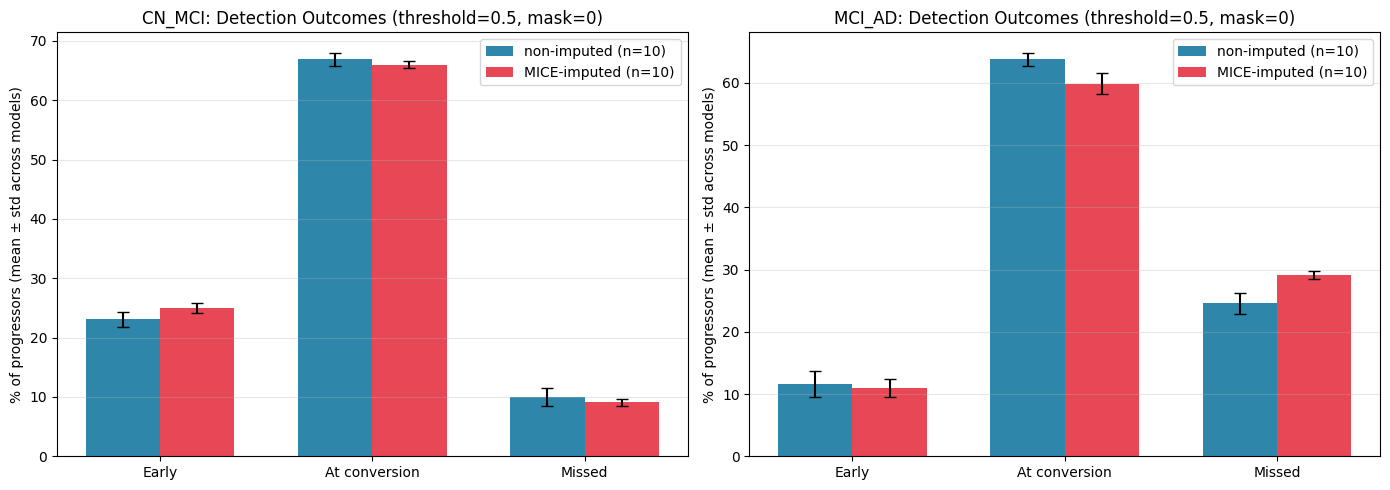

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Config ────────────────────────────────────────────────────────────────
THRESHOLD = 0.5
MASK_LENGTH = 0
CACHE_ROOT = "leadtime_prob_cache"  # relative to notebook cwd, same as used earlier
IMPUTATIONS = ["non‑imputed", "MICE‑imputed"]
COHORTS = ["CN_MCI", "MCI_AD"]
STATUS_ORDER = ["detected_early", "detected_at_conversion", "missed"]
STATUS_LABELS = ["Early", "At conversion", "Missed"]

# ── Score every cached model at THRESHOLD/MASK_LENGTH using the corrected
#    conversion-month logic (get_conversion_month + analyze_run, defined above) ──
per_model_pct = {}  # {(imputation, cohort): DataFrame[model_key, early_pct, at_conv_pct, missed_pct]}

for imp in IMPUTATIONS:
    for cohort in COHORTS:
        cohort_dir = os.path.join(CACHE_ROOT, imp, cohort)
        if not os.path.isdir(cohort_dir):
            print(f"Missing cache dir: {cohort_dir}")
            continue

        rows = []
        for model_key in sorted(os.listdir(cohort_dir)):
            model_dir = os.path.join(cohort_dir, model_key)
            prog_path = os.path.join(model_dir, 'lead_time_probabilities.csv')
            ctrl_path = os.path.join(model_dir, 'control_probabilities.csv')
            if not (os.path.exists(prog_path) and os.path.exists(ctrl_path)):
                continue

            prog_df = pd.read_csv(prog_path)
            ctrl_df = pd.read_csv(ctrl_path)
            for df in (prog_df, ctrl_df):
                df['months_since_baseline'] = df['months_since_baseline'].apply(_parse_list)
                df['Progression'] = df['Progression'].apply(_parse_list)

            res = analyze_run(prog_df, ctrl_df, THRESHOLD, MASK_LENGTH)
            n_prog = res['n_prog']
            if n_prog == 0:
                continue
            rows.append({
                'model_key': model_key,
                'early_pct': res['n_early'] / n_prog * 100,
                'at_conv_pct': res['n_at_conv'] / n_prog * 100,
                'missed_pct': res['n_missed'] / n_prog * 100,
            })

        per_model_pct[(imp, cohort)] = pd.DataFrame(rows)

# ── Plot: grouped bar chart per cohort, comparing non-imputed vs MICE-imputed,
#    averaged across all seeds/variants with error bars = std across models ──
colors = {"non‑imputed": "#2E86AB", "MICE‑imputed": "#E84855"}
bar_width = 0.35
x = np.arange(len(STATUS_LABELS))

fig, axes = plt.subplots(1, len(COHORTS), figsize=(7 * len(COHORTS), 5))
if len(COHORTS) == 1:
    axes = [axes]

for ax, cohort in zip(axes, COHORTS):
    for i, imp in enumerate(IMPUTATIONS):
        df = per_model_pct.get((imp, cohort))
        if df is None or df.empty:
            continue
        means = [df['early_pct'].mean(), df['at_conv_pct'].mean(), df['missed_pct'].mean()]
        stds = [df['early_pct'].std(), df['at_conv_pct'].std(), df['missed_pct'].std()]
        offset = (i - (len(IMPUTATIONS) - 1) / 2) * bar_width
        ax.bar(x + offset, means, bar_width, yerr=stds, capsize=4,
               label=f"{imp} (n={len(df)})", color=colors[imp])

    ax.set_xticks(x)
    ax.set_xticklabels(STATUS_LABELS)
    ax.set_ylabel("% of progressors (mean ± std across models)")
    ax.set_title(f"{cohort}: Detection Outcomes (threshold={THRESHOLD}, mask={MASK_LENGTH})")
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("leadtime_detection_outcomes_averaged.png", dpi=300, bbox_inches='tight')
plt.show()
